# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MRazaRashid/FlyRank_Week1/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [19]:
import os, sys, subprocess, pandas as pd , numpy as np
# IN_COLAB = "google.colab" in sys.modules
# REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
# REPO_DIR = "flyrank-ml-internship-starter"

# if IN_COLAB:
#     if not os.path.isdir(REPO_DIR):
#         subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
#     os.chdir(REPO_DIR)
#     subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
# elif os.path.basename(os.getcwd()) == "notebooks":
#     os.chdir("..")

# print("Working dir:", os.getcwd())
# assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
# print("Starter data found.")

In [20]:
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)]
df = df.drop_duplicates(subset="content_id")

# --- Rebuild the same client-grouped split from Week 5 ---
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

feature_cols = ["impressions_90d", "content_age_days", "days_since_last_update",
                 "avg_position", "ctr", "engagement_rate", "word_count"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df = df.iloc[train_idx]

X_train = train_df[feature_cols].fillna(0)
y_train = (train_df["trend_direction"] == "down").astype(int)

# --- Retrain the SAME model config as Week 5 ---
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

print("Model retrained. Ready to score the full dataset.")

Model retrained. Ready to score the full dataset.


In [21]:
df["model_probability"] = model.predict_proba(df[feature_cols].fillna(0))[:, 1]

def assign_action(row):
    if row["model_probability"] >= 0.65:
        return "model_decline_risk", "review"
    elif row["model_probability"] >= 0.50 and row["impressions_90d"] >= 500:
        return "visible_model_opportunity", "review"
    elif row["avg_position"] > 0 and row["avg_position"] <= 20 and row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        return "ctr_review_candidate", "improve_metadata"
    elif row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_visible_page", "refresh"
    else:
        return "no_flag", "monitor"

df[["reason_code", "action"]] = df.apply(lambda r: pd.Series(assign_action(r)), axis=1)

ranked_queue = df.sort_values("model_probability", ascending=False)[
    ["content_id", "client_id", "model_probability", "reason_code", "action",
     "impressions_90d", "avg_position", "ctr", "days_since_last_update"]
]

ranked_queue.head(20)

,content_id,client_id,model_probability,reason_code,action,impressions_90d,avg_position,ctr,days_since_last_update
12969,content_e76699b98ac6,client_19581e27de,1.0,model_decline_risk,review,790,2.2,0.00,104
451,content_678083d0c5e4,client_3fdba35f04,1.0,model_decline_risk,review,703,15.3,0.00,19
22740,content_3ce3acdf516b,client_7f2253d7e2,1.0,model_decline_risk,review,3427,15.8,0.20,20
15117,content_bb6ebb5ec8c8,client_3fdba35f04,1.0,model_decline_risk,review,2621,12.8,0.00,104
20212,content_f9afecd7aff0,client_3fdba35f04,1.0,model_decline_risk,review,280,15.6,0.00,20
12778,content_7628907d8270,client_3fdba35f04,1.0,model_decline_risk,review,504,26.7,0.00,104
529,content_c092ace0d33a,client_3fdba35f04,1.0,model_decline_risk,review,416,3.8,0.00,20
11347,content_21c32d354846,client_3fdba35f04,1.0,model_decline_risk,review,1244,31.5,0.00,104
6159,content_c71eefc9a1e1,client_3fdba35f04,1.0,model_decline_risk,review,3524,21.0,0.11,104
16638,content_d52251d98ddc,client_6208ef0f77,1.0,model_decline_risk,review,369,13.8,0.00,104


**Plain-words explanation (what a human reviewer would actually read):**

This queue ranks pages by how likely they are to be declining, based on a model trained on staleness, demand, position, and CTR signals. The top of the list is where a reviewer should start. Each row has one reason code explaining why it's flagged:

model_decline_risk — the model is highly confident (65%+) this page is declining
visible_model_opportunity — moderately confident (50%+), and the page has real traffic, so a miss here would be more costly
ctr_review_candidate — the page ranks well but isn't converting impressions into clicks — likely a title/meta problem
stale_visible_page — hasn't been touched in 6+ months but still gets real traffic
no_flag — none of the above; deprioritize

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this:**

A content strategist or SEO reviewer with limited weekly review capacity (e.g. 20-50 pages), deciding where to spend that time first.

**What it's for**:

 Prioritizing which pages to look at, not deciding what specific edit to make, and not replacing human judgment about whether a page is actually worth the effort.

**Where it stops being valid:**

This model was trained and validated on one starter dataset from one snapshot in time — it has not been tested on live, ongoing production data
The label (trend_direction == "down") is a same-window proxy, not a true future-outcome — so "declining" here means "recently trended down," not "guaranteed to keep declining"
Validated only with a client-grouped split at 0.66 precision@50 (33 of the top 50 are real hits) — meaning roughly 1 in 3 flagged pages in the top 50 will NOT be a genuine decline case, and a reviewer should expect that error rate, not treat every flagged page as certain
Not validated on clients/industries outside this dataset's 32-client starter sample
Does not account for deliberate business decisions (e.g. a page intentionally being sunset, or content nearing end-of-life for non-SEO reasons)

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting on any flagged page:**

Is the "decline" consistent with a real trend over multiple weeks, or could it be a short blip / seasonal dip (per the lane guide's decline-vs-seasonality distinction)?


Is there a sibling/related page on the same site that may have absorbed the traffic (consolidation, not decline)?


Is this page intentionally scheduled for retirement, or does it serve a purpose outside pure SEO traffic (e.g. legal, support documentation)?

Does the client have context (a known algorithm update, a site migration, a paused campaign) that would explain the pattern better than "this page needs a refresh"?

**What should NEVER be automated:**

Publishing or editing live content without human review, this tool only produces a review queue, not autonomous edits


Merging or removing pages (a "no-go" action) based solely on the model's score ,page removal/consolidation has SEO and business risk that requires a human decision


Treating the model's score as a client-facing performance claim (e.g. never tell a client "our model proved this page failed"), it's an internal prioritization aid only


Making causal claims to clients (e.g. "refreshing this page will recover the traffic"), the model does not establish causation, only correlation-based prioritization

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signs the recommendations have gone stale:**

The proportion of no_flag pages drifts sharply from what was seen in the validation set — could mean the underlying data distribution has shifted (a new client type, a platform change)


Reviewer feedback shows a rising share of flagged pages being marked "not actually declining" upon manual check — a real-world precision drop below the validated 0.66 benchmark


A significant time gap since the model was trained (e.g. 6+ months) — search behavior, SERP features, and client mix can shift enough to degrade the original signal relationships


A major platform/algorithm change is known to have occurred (e.g. a Google core update) — the underlying avg_position/CTR relationships the model learned may no longer hold

**Retrain trigger:**

if reviewer-reported precision drops meaningfully below ~0.5 (roughly matching the original decision to prefer the model over the 0.30 baseline), or every 2-3 months as a standing cadence, whichever comes first.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [23]:
import os, json

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

metrics = {
    "baseline_precision_at_50": 0.30,
    "model_precision_at_50": 0.66,
    "model_roc_auc_grouped_split": 0.586716,
    "model_average_precision": 0.586954,
    "naive_split_auc_inflated": 0.753483,
    "false_positives": 1472,
    "false_negatives": 1229,
    "top_features": ["impressions_90d", "avg_position", "ctr", "content_age_days"]
}
with open("work/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Exported queue and metrics.")
print("Confirm files exist:", os.listdir("work/outputs"))

Exported queue and metrics.
Confirm files exist: ['model_metrics.json', 'action_playbook_queue.csv']


In [25]:
from sklearn.inspection import permutation_importance

# Rebuild the test set (matching Week 5's split) to compute importance on
X_test = df.iloc[test_idx][feature_cols].fillna(0)
y_test = (df.iloc[test_idx]["trend_direction"] == "down").astype(int)

perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print(importance_df)

                  feature  importance
0         impressions_90d    0.048970
3            avg_position    0.013094
4                     ctr    0.012121
1        content_age_days    0.007837
5         engagement_rate   -0.001655
6              word_count   -0.007448
2  days_since_last_update   -0.011894


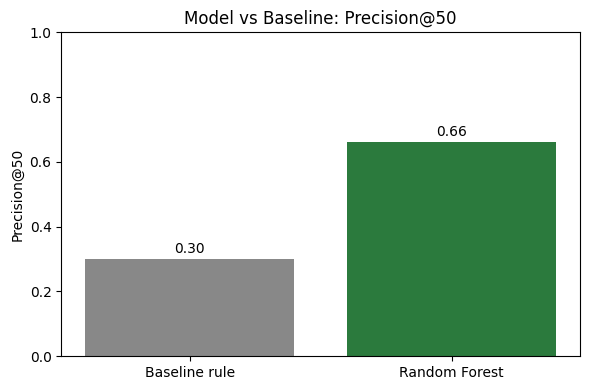

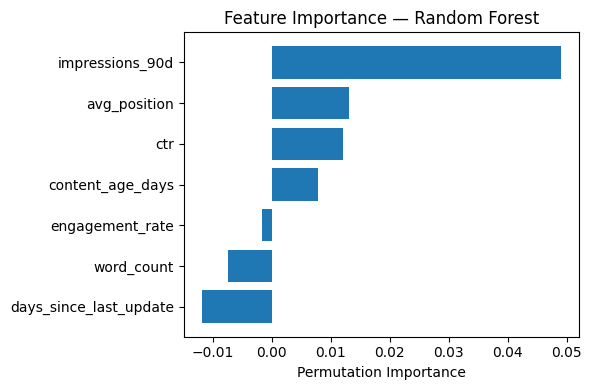

Figures saved: ['feature_importance.png', 'model_vs_baseline_precision.png']


In [26]:
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# Figure 1: Model vs Baseline comparison
fig, ax = plt.subplots(figsize=(6,4))
methods = ["Baseline rule", "Random Forest"]
precisions = [0.30, 0.66]
ax.bar(methods, precisions, color=["#888888", "#2b7a3d"])
ax.set_ylabel("Precision@50")
ax.set_title("Model vs Baseline: Precision@50")
ax.set_ylim(0, 1)
for i, v in enumerate(precisions):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline_precision.png", dpi=150)
plt.show()

# Figure 2: Feature importance (from your Week 5/6 permutation importance)
fig, ax = plt.subplots(figsize=(6,4))
importance_df_sorted = importance_df.sort_values("importance")
ax.barh(importance_df_sorted["feature"], importance_df_sorted["importance"])
ax.set_xlabel("Permutation Importance")
ax.set_title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()

print("Figures saved:", os.listdir("work/figures"))

In [18]:
# print("Current working directory:", os.getcwd())
# print()
# print("Does work/outputs exist?", os.path.exists("work/outputs"))
# print("Does work/figures exist?", os.path.exists("work/figures"))
# print()
# if os.path.exists("work"):
#     print("Contents of work/:", os.listdir("work"))
# if os.path.exists("work/outputs"):
#     print("Contents of work/outputs/:", os.listdir("work/outputs"))

# import shutil

# if os.path.isdir("flyrank-ml-internship-starter"):
#     shutil.rmtree("flyrank-ml-internship-starter")
#     print("Removed leftover nested folder.")

# print("Files here now:", os.listdir("."))

Removed leftover nested folder.
Files here now: ['SETUP.md', 'README.md', '.git', 'outputs', 'scripts', '.github', 'DATA_USE.md', 'data', 'work', 'requirements.txt', 'CLAUDE.md', 'submission', 'notebooks', '.gitignore', 'LICENSE', 'GUIDE.md', 'AGENTS.md', 'docs', 'skills']


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.